In [3]:
import pandas as pd
df = pd.read_excel('week4-dataset.xlsx')

print('First 5 rows:')
print(df.head())

First 5 rows:
      Segment  Country    Product Discount Band  Units Sold  \
0  Government  Germany  Carretera           NaN      1513.0   
1  Government  Germany      Paseo           NaN      1006.0   
2  Government   Canada      Paseo           NaN      1725.0   
3  Government  Germany      Paseo           NaN      1513.0   
4  Government  Germany       Velo           NaN      1006.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts     Sales  \
0                    3         350     529550.0        0.0  529550.0   
1                   10         350     352100.0        0.0  352100.0   
2                   10         350     603750.0        0.0  603750.0   
3                   10         350     529550.0        0.0  529550.0   
4                  120         350     352100.0        0.0  352100.0   

       COGS    Profit       Date  Month Number Month Name  Year  
0  393380.0  136170.0 2014-12-01            12   December  2014  
1  261560.0   90540.0 2014-06-01          

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 700
Columns: 16


In [14]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    str           
 1   Country              700 non-null    str           
 2   Product              700 non-null    str           
 3   Discount Band        647 non-null    str           
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[us]
 13  Month Number         700 non-null    int64    

Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [15]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2014-04-28 21:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013-12-24 06:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,2014-05-16 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014-09-08 12:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-12-01 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,NaN,3.377321,0.433322


In [16]:
df["Discount Band"] = df["Discount Band"].fillna("Unknown")

In [17]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
 Sales                 0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [28]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [29]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Units Sold:", df["Units Sold"].sum())

Total Sales: 118726350.25999999
Total Profit: 16893702.26
Total Units Sold: 1125806.0


In [30]:
sales_country = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_country)


Country
United States of America    2.502983e+07
Canada                      2.488765e+07
France                      2.435417e+07
Germany                     2.350534e+07
Mexico                      2.094935e+07
Name: Sales, dtype: float64


In [31]:
sales_product = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_product)

Product
Paseo        3.301114e+07
VTT          2.051192e+07
Velo         1.825006e+07
Amarilla     1.774712e+07
Montana      1.539080e+07
Carretera    1.381531e+07
Name: Sales, dtype: float64


In [32]:
sales_segment = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_segment)


Segment
Government          5.250426e+07
Small Business      4.242792e+07
Enterprise          1.961169e+07
Midmarket           2.381883e+06
Channel Partners    1.800594e+06
Name: Sales, dtype: float64


In [34]:
sales_year = (
    df.groupby("Year")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_year)


Year
2014    92311094.75
2013    26415255.51
Name: Sales, dtype: float64


In [35]:
profit_margin = df["Profit"].sum() / df["Sales"].sum() * 100

print(f"Overall Profit Margin: {profit_margin:.2f}%")

Overall Profit Margin: 14.23%


In [36]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_percentage = (
    segment_sales / df["Sales"].sum() * 100
).sort_values(ascending=False)

print(segment_percentage)

Segment
Government          44.222921
Small Business      35.735890
Enterprise          16.518401
Midmarket            2.006196
Channel Partners     1.516591
Name: Sales, dtype: float64


In [37]:
sales_2013 = df.loc[df["Year"] == 2013, "Sales"].sum()
sales_2014 = df.loc[df["Year"] == 2014, "Sales"].sum()

growth = (sales_2014 - sales_2013) / sales_2013 * 100

print(f"Sales Growth from 2013 to 2014: {growth:.2f}%")

Sales Growth from 2013 to 2014: 249.46%


In [38]:
print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

Earliest date: 2013-09-01 00:00:00
Latest date: 2014-12-01 00:00:00


In [39]:
print(df.groupby("Year")["Month Number"].agg(["min", "max"]))

      min  max
Year          
2013    9   12
2014    1   12


In [40]:
print(
    df.groupby(["Year", "Month Number"])["Sales"]
      .sum()
      .sort_index()
)

Year  Month Number
2013  9                4484000.03
      10               9295611.10
      11               7267203.30
      12               5368441.08
2014  1                6607761.68
      2                7297531.39
      3                5586859.87
      4                6964775.07
      5                6210211.06
      6                9518893.82
      7                8102920.18
      8                5864622.42
      9                6398697.24
      10              12375819.92
      11               5384214.20
      12              11998787.90
Name: Sales, dtype: float64


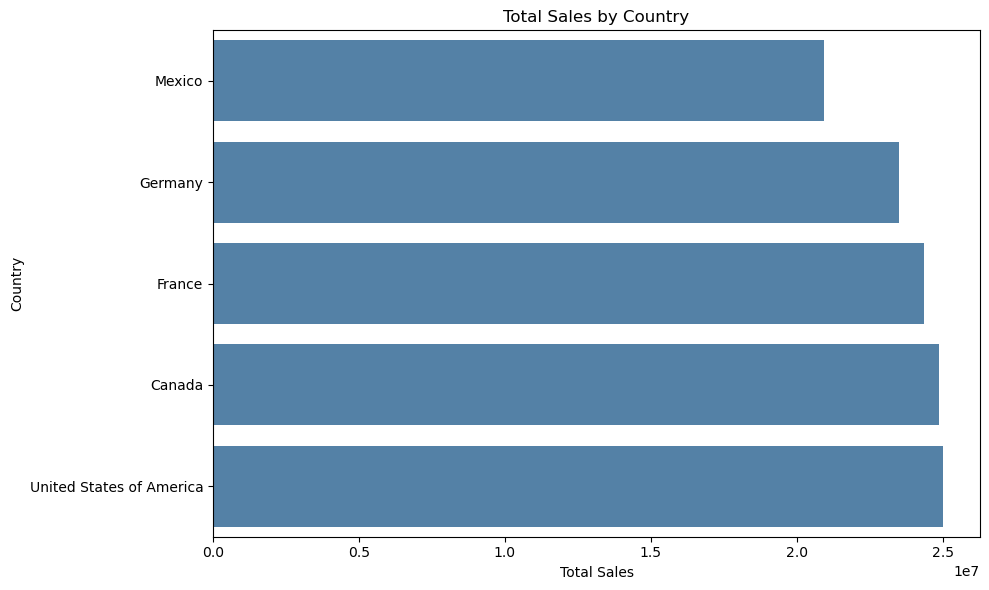

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_country = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=sales_country.values,
    y=sales_country.index,
    color="steelblue"
)

plt.title("Total Sales by Country")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

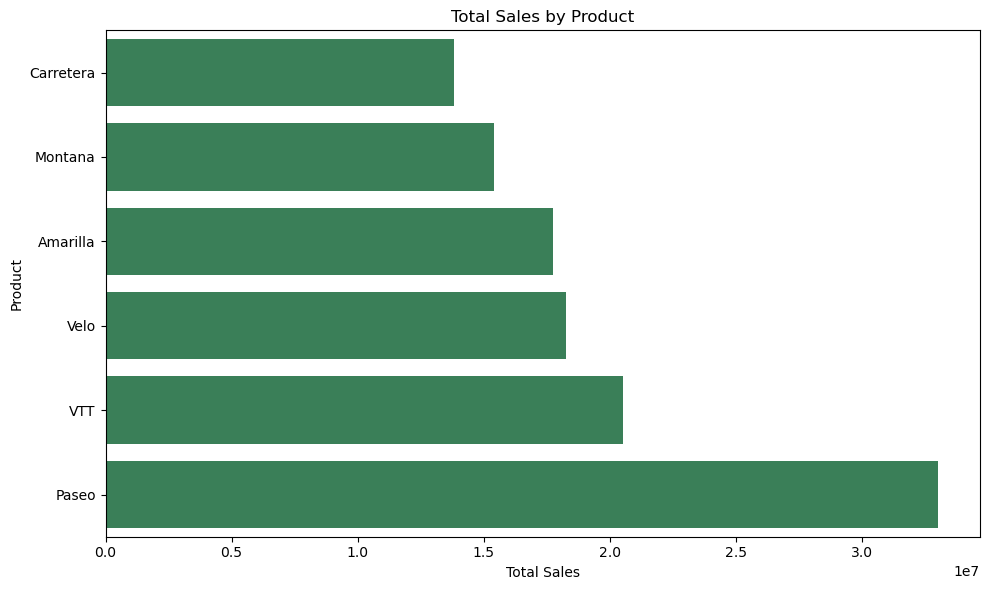

In [42]:
sales_product = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=sales_product.values,
    y=sales_product.index,
    color="seagreen"
)

plt.title("Total Sales by Product")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

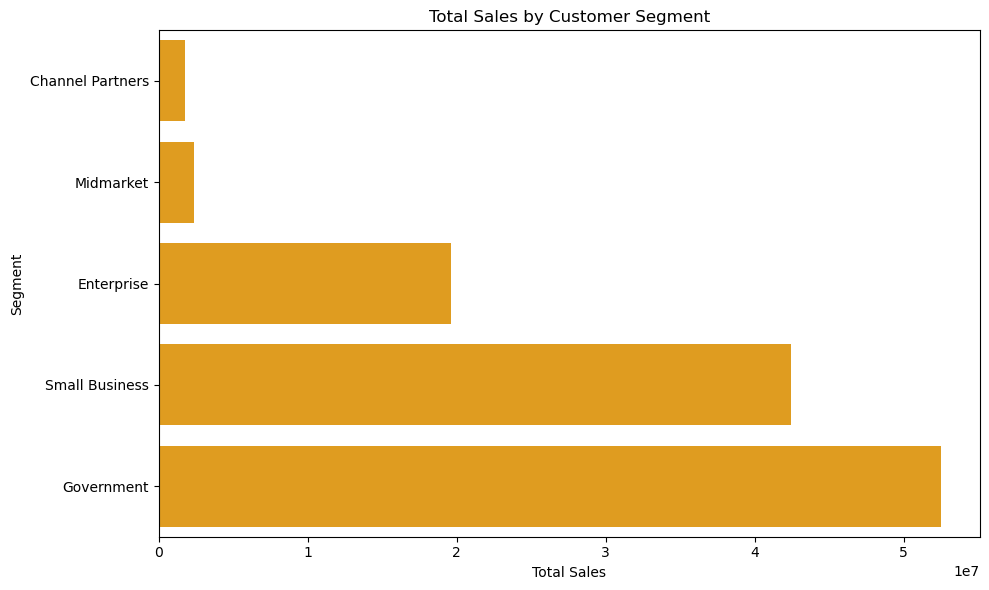

In [43]:
sales_segment = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=sales_segment.values,
    y=sales_segment.index,
    color="orange"
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Total Sales")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

In [44]:
print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

print(df.groupby("Year")["Month Number"].agg(["min", "max"]))

print(
    df.groupby(["Year", "Month Number"])["Sales"]
      .sum()
      .sort_index()
)

Earliest date: 2013-09-01 00:00:00
Latest date: 2014-12-01 00:00:00
      min  max
Year          
2013    9   12
2014    1   12
Year  Month Number
2013  9                4484000.03
      10               9295611.10
      11               7267203.30
      12               5368441.08
2014  1                6607761.68
      2                7297531.39
      3                5586859.87
      4                6964775.07
      5                6210211.06
      6                9518893.82
      7                8102920.18
      8                5864622.42
      9                6398697.24
      10              12375819.92
      11               5384214.20
      12              11998787.90
Name: Sales, dtype: float64


In [45]:
profit_product = (
    df.groupby("Product")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_product)

Product
Paseo        4797437.950
VTT          3034608.020
Amarilla     2814104.060
Velo         2305992.465
Montana      2114754.880
Carretera    1826804.885
Name: Profit, dtype: float64


In [46]:
profit_country = (
    df.groupby("Country")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_country)


Country
France                      3781020.780
Germany                     3680388.820
Canada                      3529228.885
United States of America    2995540.665
Mexico                      2907523.110
Name: Profit, dtype: float64


In [47]:
profit_segment = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_segment)

Segment
Government          1.138817e+07
Small Business      4.143168e+06
Channel Partners    1.316803e+06
Midmarket           6.601031e+05
Enterprise         -6.145456e+05
Name: Profit, dtype: float64


In [48]:
loss_rows = df[df["Profit"] < 0]

print("Loss-making transactions:", len(loss_rows))
print("Total loss:", loss_rows["Profit"].sum())

Loss-making transactions: 58
Total loss: -777321.25


In [49]:
loss_by_product = (
    loss_rows.groupby("Product")["Profit"]
    .sum()
    .sort_values()
)

print(loss_by_product)

Product
Carretera   -231110.00
Velo        -125456.25
Amarilla    -121940.00
VTT         -121740.00
Paseo       -120548.75
Montana      -56526.25
Name: Profit, dtype: float64


In [50]:
discount_analysis = df.groupby("Discount Band").agg(
    Total_Sales=("Sales", "sum"),
    Total_Discounts=("Discounts", "sum"),
    Total_Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum")
).sort_values("Total_Sales", ascending=False)

print(discount_analysis)

                Total_Sales  Total_Discounts  Total_Profit  Units_Sold
Discount Band                                                         
Medium         3.878043e+07      3002546.165   5579522.835    379698.5
High           3.737249e+07      5317026.275   3388866.725    398085.5
Low            3.462978e+07       885675.800   6188857.700    261858.5
Unknown        7.943654e+06            0.000   1736455.000     86163.5


In [51]:
product_analysis = df.groupby("Product").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum")
)

product_analysis["Profit_Margin_%"] = (
    product_analysis["Profit"] / product_analysis["Sales"] * 100
)

print(product_analysis.sort_values("Profit_Margin_%", ascending=False))

                  Sales       Profit  Units_Sold  Profit_Margin_%
Product                                                          
Amarilla   1.774712e+07  2814104.060    155315.0        15.856684
VTT        2.051192e+07  3034608.020    168783.0        14.794363
Paseo      3.301114e+07  4797437.950    338239.5        14.532783
Montana    1.539080e+07  2114754.880    154198.0        13.740381
Carretera  1.381531e+07  1826804.885    146846.0        13.223049
Velo       1.825006e+07  2305992.465    162424.5        12.635534


In [52]:
country_analysis = df.groupby("Country").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

country_analysis["Profit_Margin_%"] = (
    country_analysis["Profit"] / country_analysis["Sales"] * 100
)

print(country_analysis.sort_values("Profit_Margin_%", ascending=False))

                                 Sales       Profit  Profit_Margin_%
Country                                                             
Germany                   2.350534e+07  3680388.820        15.657671
France                    2.435417e+07  3781020.780        15.525146
Canada                    2.488765e+07  3529228.885        14.180641
Mexico                    2.094935e+07  2907523.110        13.878821
United States of America  2.502983e+07  2995540.665        11.967883


In [53]:
segment_analysis = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

segment_analysis["Profit_Margin_%"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"] * 100
)

print(segment_analysis.sort_values("Profit_Margin_%", ascending=False))

                         Sales        Profit  Profit_Margin_%
Segment                                                      
Channel Partners  1.800594e+06  1.316803e+06        73.131611
Midmarket         2.381883e+06  6.601031e+05        27.713496
Government        5.250426e+07  1.138817e+07        21.689998
Small Business    4.242792e+07  4.143168e+06         9.765194
Enterprise        1.961169e+07 -6.145456e+05        -3.133567


In [54]:
discount_margin = df.groupby("Discount Band").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Discounts=("Discounts", "sum")
)

discount_margin["Profit_Margin_%"] = (
    discount_margin["Profit"] / discount_margin["Sales"] * 100
)

print(discount_margin.sort_values("Profit_Margin_%", ascending=False))

                      Sales       Profit    Discounts  Profit_Margin_%
Discount Band                                                         
Unknown        7.943654e+06  1736455.000        0.000        21.859650
Low            3.462978e+07  6188857.700   885675.800        17.871491
Medium         3.878043e+07  5579522.835  3002546.165        14.387470
High           3.737249e+07  3388866.725  5317026.275         9.067812


In [55]:
print(df.columns.tolist())
print(df.isnull().sum())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']
Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64


In [56]:
features = [
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Country",
    "Product",
    "Segment",
    "Discount Band",
    "Month Number",
    "Year"
]

X = df[features]
y = df["Sales"]


In [57]:
categorical_features = [
    "Country",
    "Product",
    "Segment",
    "Discount Band"
]

numerical_features = [
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Month Number",
    "Year"
]

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 560
Testing rows: 140


In [61]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [62]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [63]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[-58605.02861318 335355.17792502 167271.60543576  39238.17642879
  57419.8538981  342573.53527261  88304.03954526 125012.26736314
  76441.23911959 328644.66223352]


In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE: $82,876.54
RMSE: $114,244.40
R² Score: 0.7643


In [65]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print(comparison.head(10))

   Actual Sales  Predicted Sales
0     12066.600    -58605.028613
1    230310.000    335355.177925
2     40769.250    167271.605436
3     27968.000     39238.176429
4     23436.000     57419.853898
5     31133.025    342573.535273
6     15474.550     88304.039545
7     18035.920    125012.267363
8     32670.000     76441.239120
9    334302.500    328644.662234


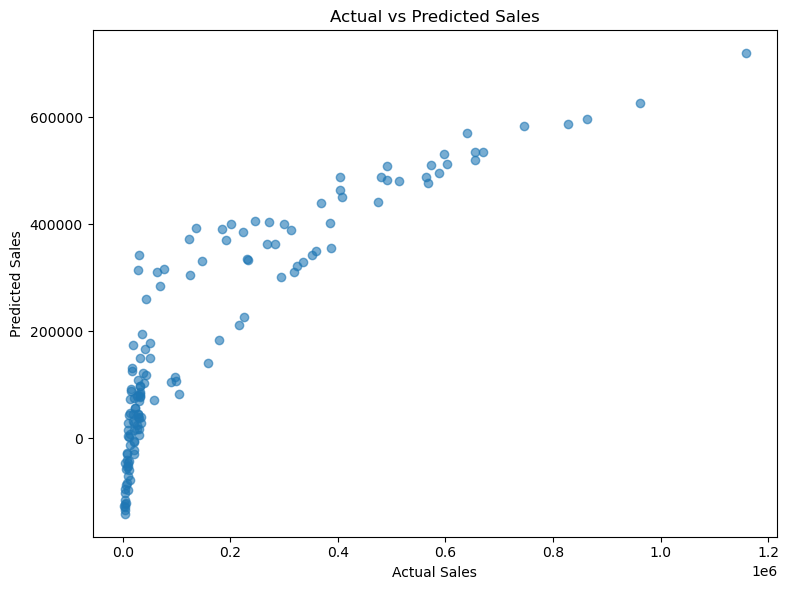

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.show()

In [67]:
from sklearn.ensemble import RandomForestRegressor

In [68]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            n_jobs=-1
        ))
    ]
)

In [69]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [70]:
rf_pred = rf_model.predict(X_test)

In [71]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE: ${rf_mae:,.2f}")
print(f"Random Forest RMSE: ${rf_rmse:,.2f}")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest MAE: $11,129.46
Random Forest RMSE: $29,469.93
Random Forest R²: 0.9843


In [72]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "R2": [
        r2,
        rf_r2
    ]
})

print(model_comparison)

               Model           MAE           RMSE        R2
0  Linear Regression  82876.544373  114244.400559  0.764336
1      Random Forest  11129.460905   29469.926694  0.984319


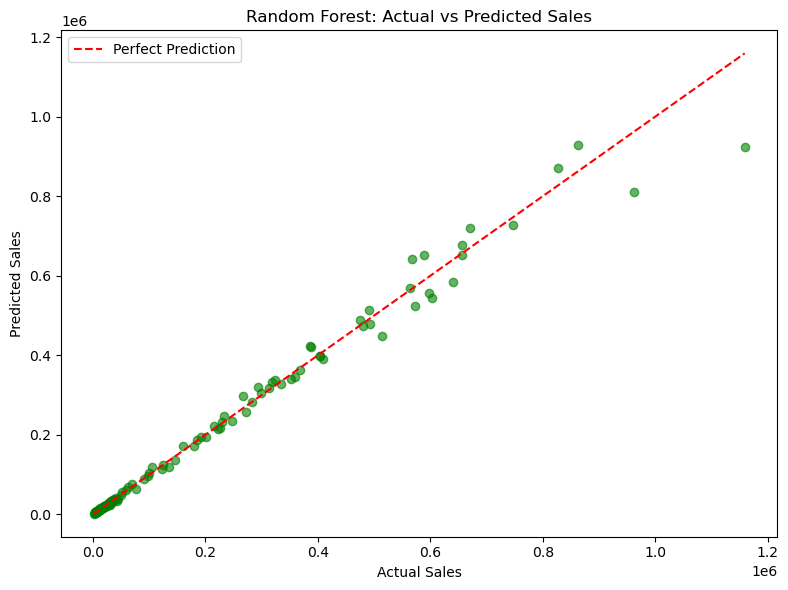

In [73]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.6, color="green")

# Perfect prediction line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted Sales")
plt.legend()

plt.tight_layout()
plt.show()


In [74]:
rf_comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": rf_pred
})

rf_comparison["Prediction Error"] = (
    rf_comparison["Actual Sales"] -
    rf_comparison["Predicted Sales"]
)

print(rf_comparison.head(10))

   Actual Sales  Predicted Sales  Prediction Error
0     12066.600     11844.393800        222.206200
1    230310.000    232322.959167      -2012.959167
2     40769.250     41403.242083       -633.992083
3     27968.000     27574.953833        393.046167
4     23436.000     21929.713600       1506.286400
5     31133.025     22848.199267       8284.825733
6     15474.550     15023.963033        450.586967
7     18035.920     18174.922733       -139.002733
8     32670.000     31249.163500       1420.836500
9    334302.500    328449.200000       5853.300000


In [75]:
print(features)

['Units Sold', 'Manufacturing Price', 'Sale Price', 'Country', 'Product', 'Segment', 'Discount Band', 'Month Number', 'Year']


In [76]:
with pd.ExcelWriter("Sales_Analysis.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    sales_country.to_excel(writer, sheet_name="Sales by Country")
    sales_product.to_excel(writer, sheet_name="Sales by Product")
    sales_segment.to_excel(writer, sheet_name="Sales by Segment")
    profit_product.to_excel(writer, sheet_name="Profit by Product")
    profit_country.to_excel(writer, sheet_name="Profit by Country")
    profit_segment.to_excel(writer, sheet_name="Profit by Segment")
    discount_analysis.to_excel(writer, sheet_name="Discount Analysis")